# Predicting Loan Approval for FinTech Innovations

## Overview
This project focuses on predicting credit approval for FinTech Innovations, an operational bottleneck currently weighed down by legacy, manual underwriting methods. After testing five different machine learning algorithms, I selected Logistic Regression as the final architecture due to its transparent interpretability. Crucially, instead of blindly trusting the default 0.5 classification threshold, I optimized a custom threshold at 0.92 to mirror the business's actual asymmetric risk—where a bad  default costs 6.25 times more (50,000 dollars) than a missed creditworthy opportunity ($8,000 ).

On the held-out test data, shifting to this tighter 0.92 limit slashed the total financial burden of approval mistakes by an outstanding 90.4%. Statistically, this translates to roughly $9,454 saved per application, preventing a massive 37.8 million dollars loss across the 4,000 evaluated test cases. Unsurprisingly, the biggest factor driving applicant rejections was the total debt-to-income ratio, while monthly income and net worth acted as the core drivers for approval.


## Business Understanding

1. Begin by thoroughly analyzing the business context of FinTech Innovations' loan approval process. Write a short summary that:
- Describes the current manual process and its limitations
- Identifies key stakeholders and their needs
- Explains the implications of different types of model errors
- Justifies your choice between classification and regression approaches

2. Define your modeling goals and success criteria:
- Select appropriate evaluation metrics based on business impact
- You must use at least two different metrics
- Consider creating custom metric
- Establish baseline performance targets
- Document your reasoning for each choice
  
### Business Understanding and Planning

FinTech Innovations currently relies heavily on manual loan application reviews,
which can make the approval process slower and lead to inconsistent decisions.
The main stakeholders are loan officers, the risk analytics team, management, and
loan applicants. Loan officers need faster, more consistent decisions so they can
focus on genuinely borderline cases. The risk analytics team needs a model that is
accurate and explainable enough to defend to regulators. Management needs reduced
losses from bad approvals without turning away creditworthy customers. Applicants
need fast, fair, and transparent decisions. The model should help make the screening
process more consistent while supporting loan officers in making decisions.
The costs of incorrect decisions are different. Approving a bad loan that defaults
has an estimated cost of $50,000, while rejecting a creditworth applicant has an estimated lost profit of 8,000 dollars.    
I chose classification because the dataset contains `LoanApproved`, which indicates
whether a loan application was approved or not. The classification model therefore
predicts the historical approval decision. A regression approach could instead be
used to predict `RiskScore`, but classification is more directly aligned with the
approval-decision objective.

Modeling Goals and Metrics
The main metric is ROC-AUC, supported by precision, recall, and F1-score. Accuracy
is also considered, but it is not used alone because the target classes are
imbalanced.
I also created a custom business-cost metric that considers the different costs of
incorrect decisions:
- False positive: $50,000
    
- False negative: $8,000

As a baseline, any deployed model must clearly outperform a naive random classifier
(which would score close to 0.50 ROC-AUC by chance) and must meaningfully reduce
total business cost compared to a simple approve-everyone or deny-everyone policy.
This comparison is carried out once models have been trained, in the Evaluation
section.
The model will therefore be evaluated using both predictive performance and
estimated business cost.


## Data Understanding
3. Conduct comprehensive exploratory data analysis:
- Describe basic data characteristics
- Examine distributions of all features and target variables
- Investigate relationships between features
- Create visualizations to help aid in EDA
- Document potential data quality issues and their implications

4. Develop feature understanding:
- Categorize features by type (numerical, categorical, ordinal)
- Identify features requiring special preprocessing
- Document missing value patterns and their potential meanings
- Note potential feature engineering opportunities

### Data Understanding and Exploration
The dataset contains 20,000 loan applications and 35 variables covering applicant demographics, income, credit history, debts, assets, loan information, and approval outcomes.

The following analysis examines:

Data types and missing values  
Numerical and categorical variables  
Target distribution   
Relationships between features and loan approval   
Correlations between numerical variables   
Statistical differences between approved and rejected applications   
Potential features that should be excluded from modeling   

In [155]:
# Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, GridSearchCV, RandomizedSearchCV, StratifiedKFold,cross_val_score
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer,KNNImputer
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (roc_auc_score, roc_curve, classification_report, confusion_matrix,ConfusionMatrixDisplay, r2_score, mean_squared_error, mean_absolute_error)

In [156]:
# load data
df = pd.read_csv('financial_loan_data.csv')
print(df.shape)
df.head()

(20000, 35)


,Age,AnnualIncome,CreditScore,EmploymentStatus,EducationLevel,Experience,LoanAmount,LoanDuration,MaritalStatus,NumberOfDependents,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
0,45,"$39,948.00",617,Employed,Master,22,13152,48,Married,2,...,3329.000000,0.724972,11,126928,0.199652,0.227590,419.805992,0.181077,0,49.0
1,38,"$39,709.00",628,Employed,Associate,15,26045,48,Single,1,...,3309.083333,0.935132,3,43609,0.207045,0.201077,794.054238,0.389852,0,52.0
2,47,"$40,724.00",570,Employed,Bachelor,26,17627,36,NaN,2,...,3393.666667,0.872241,6,5205,0.217627,0.212548,666.406688,0.462157,0,52.0
3,58,"$69,084.00",545,Employed,High School,34,37898,96,Single,1,...,5757.000000,0.896155,5,99452,0.300398,0.300911,1047.506980,0.313098,0,54.0
4,37,"$103,264.00",594,Employed,Associate,17,9184,36,Married,1,...,8605.333333,0.941369,5,227019,0.197184,0.175990,330.179140,0.070210,1,36.0


In [157]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 35 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         20000 non-null  int64  
 1   AnnualIncome                20000 non-null  object 
 2   CreditScore                 20000 non-null  int64  
 3   EmploymentStatus            20000 non-null  object 
 4   EducationLevel              19099 non-null  object 
 5   Experience                  20000 non-null  int64  
 6   LoanAmount                  20000 non-null  int64  
 7   LoanDuration                20000 non-null  int64  
 8   MaritalStatus               18669 non-null  object 
 9   NumberOfDependents          20000 non-null  int64  
 10  HomeOwnershipStatus         20000 non-null  object 
 11  MonthlyDebtPayments         20000 non-null  int64  
 12  CreditCardUtilizationRate   20000 non-null  float64
 13  NumberOfOpenCreditLines     200

In [158]:
df.describe()

,Age,CreditScore,Experience,LoanAmount,LoanDuration,NumberOfDependents,MonthlyDebtPayments,CreditCardUtilizationRate,NumberOfOpenCreditLines,NumberOfCreditInquiries,...,MonthlyIncome,UtilityBillsPaymentHistory,JobTenure,NetWorth,BaseInterestRate,InterestRate,MonthlyLoanPayment,TotalDebtToIncomeRatio,LoanApproved,RiskScore
count,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,...,20000.000000,20000.000000,20000.000000,2.000000e+04,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000,20000.000000
mean,39.752600,571.612400,17.522750,24882.867800,54.057000,1.517300,454.292700,0.286381,3.023350,0.993000,...,4891.715521,0.799918,5.002650,7.229432e+04,0.239124,0.239110,911.607052,0.402182,0.239000,50.766780
std,11.622713,50.997358,11.316836,13427.421217,24.664857,1.386325,240.507609,0.159793,1.736161,0.986965,...,3296.771598,0.120665,2.236804,1.179200e+05,0.035509,0.042205,674.583473,0.338924,0.426483,7.778262
min,18.000000,343.000000,0.000000,3674.000000,12.000000,0.000000,50.000000,0.000974,0.000000,0.000000,...,1250.000000,0.259203,0.000000,1.000000e+03,0.130101,0.113310,97.030193,0.016043,0.000000,28.800000
25%,32.000000,540.000000,9.000000,15575.000000,36.000000,0.000000,286.000000,0.160794,2.000000,0.000000,...,2629.583333,0.727379,3.000000,8.734750e+03,0.213889,0.209142,493.763700,0.179693,0.000000,46.000000
50%,40.000000,578.000000,17.000000,21914.500000,48.000000,1.000000,402.000000,0.266673,3.000000,1.000000,...,4034.750000,0.820962,5.000000,3.285550e+04,0.236157,0.235390,728.511452,0.302711,0.000000,52.000000
75%,48.000000,609.000000,25.000000,30835.000000,72.000000,2.000000,564.000000,0.390634,4.000000,2.000000,...,6163.000000,0.892333,6.000000,8.882550e+04,0.261533,0.265532,1112.770759,0.509214,0.000000,56.000000
max,80.000000,712.000000,61.000000,184732.000000,120.000000,5.000000,2919.000000,0.917380,13.000000,7.000000,...,25000.000000,0.999433,16.000000,2.603208e+06,0.405029,0.446787,10892.629520,4.647657,1.000000,84.000000


In [159]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age,20000.0,NaN,NaN,NaN,39.7526,11.622713,18.0,32.0,40.0,48.0,80.0
AnnualIncome,20000,17516,"$15,000.00",584,NaN,NaN,NaN,NaN,NaN,NaN,NaN
CreditScore,20000.0,NaN,NaN,NaN,571.6124,50.997358,343.0,540.0,578.0,609.0,712.0
EmploymentStatus,20000,3,Employed,17036,NaN,NaN,NaN,NaN,NaN,NaN,NaN
EducationLevel,19099,5,Bachelor,5804,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Experience,20000.0,NaN,NaN,NaN,17.52275,11.316836,0.0,9.0,17.0,25.0,61.0
LoanAmount,20000.0,NaN,NaN,NaN,24882.8678,13427.421217,3674.0,15575.0,21914.5,30835.0,184732.0
LoanDuration,20000.0,NaN,NaN,NaN,54.057,24.664857,12.0,36.0,48.0,72.0,120.0
MaritalStatus,18669,4,Married,9370,NaN,NaN,NaN,NaN,NaN,NaN,NaN
NumberOfDependents,20000.0,NaN,NaN,NaN,1.5173,1.386325,0.0,0.0,1.0,2.0,5.0


In [160]:
df.columns

Index(['Age', 'AnnualIncome', 'CreditScore', 'EmploymentStatus',
       'EducationLevel', 'Experience', 'LoanAmount', 'LoanDuration',
       'MaritalStatus', 'NumberOfDependents', 'HomeOwnershipStatus',
       'MonthlyDebtPayments', 'CreditCardUtilizationRate',
       'NumberOfOpenCreditLines', 'NumberOfCreditInquiries',
       'DebtToIncomeRatio', 'BankruptcyHistory', 'LoanPurpose',
       'PreviousLoanDefaults', 'PaymentHistory', 'LengthOfCreditHistory',
       'SavingsAccountBalance', 'CheckingAccountBalance', 'TotalAssets',
       'TotalLiabilities', 'MonthlyIncome', 'UtilityBillsPaymentHistory',
       'JobTenure', 'NetWorth', 'BaseInterestRate', 'InterestRate',
       'MonthlyLoanPayment', 'TotalDebtToIncomeRatio', 'LoanApproved',
       'RiskScore'],
      dtype='object')

In [161]:
# EDA Code Here - Create New Cells As Needed
# Clean AnnualIncome and BankruptcyHistory for EDA
df_eda = df.copy()
df_eda['AnnualIncome'] = df_eda['AnnualIncome'].replace(r'[\$,]', '', regex=True).astype(float)
df_eda['BankruptcyHistory_flag'] = df_eda['BankruptcyHistory'].map({'Yes': 1, 'No': 0})

missing = df_eda.isnull().sum()
missing = missing[missing > 0]
missing_pct = (missing / len(df_eda) * 100).round(2)
pd.DataFrame({'missing_count': missing, 'missing_pct': missing_pct})

,missing_count,missing_pct
EducationLevel,901,4.50
MaritalStatus,1331,6.65
SavingsAccountBalance,572,2.86


In [162]:
# outlier detection (IQR method)
numeric_cols = ['Age','AnnualIncome','CreditScore','Experience','LoanAmount','LoanDuration',
    'MonthlyDebtPayments','CreditCardUtilizationRate','NumberOfOpenCreditLines','NumberOfCreditInquiries',
    'DebtToIncomeRatio','LengthOfCreditHistory','SavingsAccountBalance','CheckingAccountBalance',
    'TotalAssets','TotalLiabilities','MonthlyIncome','UtilityBillsPaymentHistory','JobTenure','NetWorth']

outlier_summary = []
for col in numeric_cols:
    q1, q3 = df_eda[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df_eda[col] < lower) | (df_eda[col] > upper)).sum()
    outlier_summary.append({'feature': col, 'pct_outliers': round(100 * n_out / len(df_eda), 2)})

outlier_df = pd.DataFrame(outlier_summary).sort_values('pct_outliers', ascending=False)
outlier_df

,feature,pct_outliers
19,NetWorth,7.82
12,SavingsAccountBalance,7.74
15,TotalLiabilities,7.66
13,CheckingAccountBalance,7.61
14,TotalAssets,7.21
1,AnnualIncome,4.74
16,MonthlyIncome,4.62
4,LoanAmount,3.73
6,MonthlyDebtPayments,3.72
17,UtilityBillsPaymentHistory,1.47


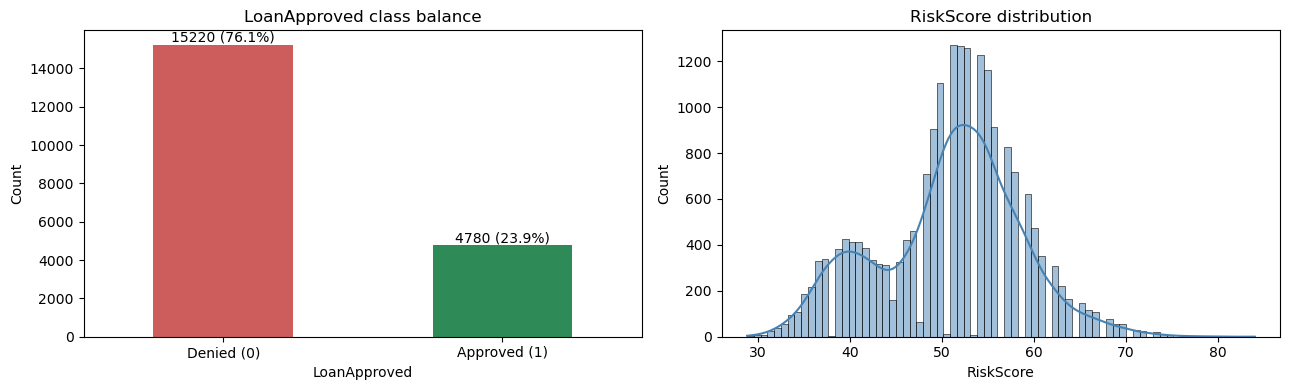

In [163]:
# Target variables distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
# LoanApproved class balance
counts = df_eda['LoanApproved'].value_counts().sort_index()
counts.plot(kind='bar', ax=axes[0], color=['indianred', 'seagreen'])
axes[0].set_xticklabels(['Denied (0)', 'Approved (1)'], rotation=0)
axes[0].set_title('LoanApproved class balance')
axes[0].set_ylabel('Count')
axes[0].bar_label(axes[0].containers[0], labels=[f"{v} ({v/len(df_eda):.1%})" for v in counts])
# RiskScore distribution
sns.histplot(df_eda['RiskScore'], kde=True, ax=axes[1], color='steelblue')
axes[1].set_title('RiskScore distribution')
axes[1].set_xlabel('RiskScore')

plt.tight_layout()
plt.show()

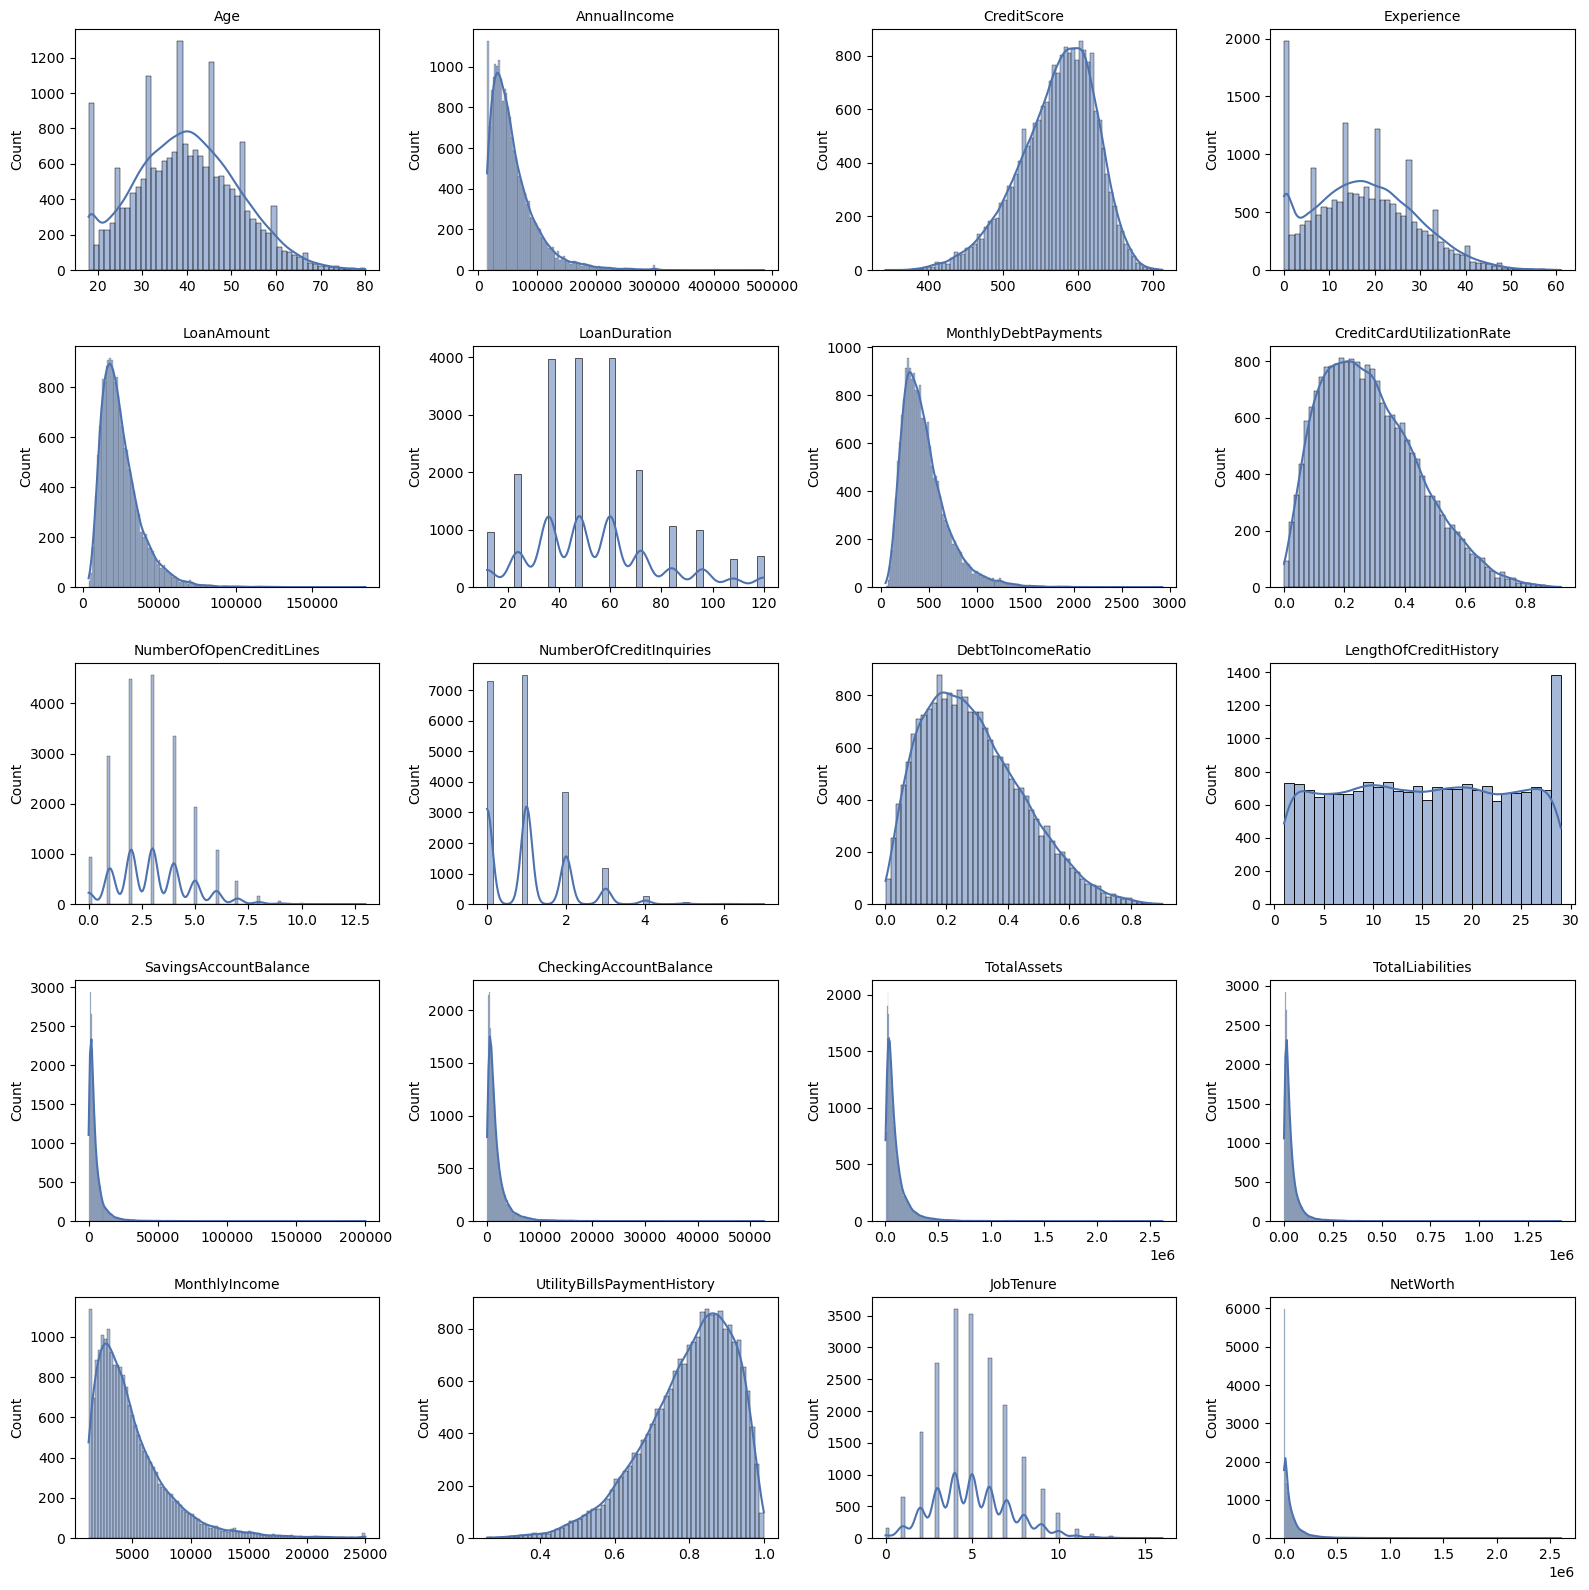

In [164]:
fig, axes = plt.subplots(5, 4, figsize=(16, 16))
for ax, col in zip(axes.flatten(), numeric_cols):
    sns.histplot(df_eda[col], kde=True, ax=ax, color='#4c72b0')
    ax.set_title(col, fontsize=10)
    ax.set_xlabel('')
plt.tight_layout()
plt.show()

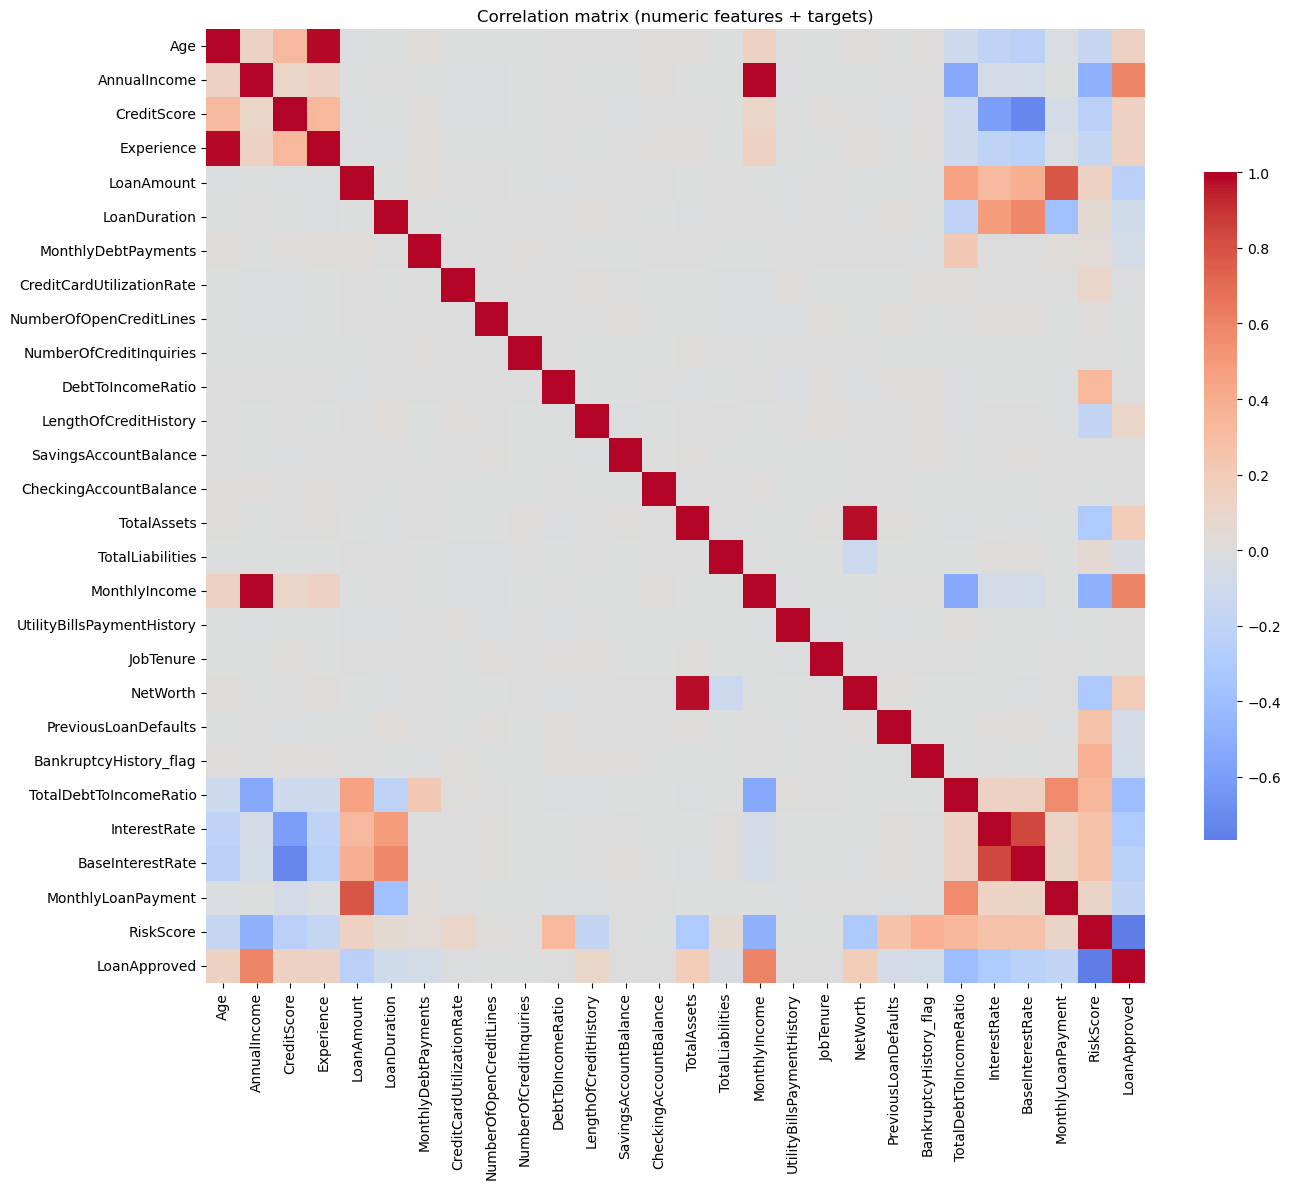

In [165]:
# Correlation heatmap of numeric features + both targets
corr_cols = numeric_cols + ['PreviousLoanDefaults', 'BankruptcyHistory_flag', 'TotalDebtToIncomeRatio',
                             'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment', 'RiskScore', 'LoanApproved']
corr = df_eda[corr_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr, cmap='coolwarm', center=0, cbar_kws={'shrink': 0.7})
plt.title('Correlation matrix (numeric features + targets)')
plt.tight_layout()
plt.show()

In [166]:
# correlation values
corr = df_eda[corr_cols].corr()
for target in ['LoanApproved', 'RiskScore']:
    print(f"Correlation with {target} (sorted):")
    print(corr[target].sort_values(ascending=False))
    print()

Correlation with LoanApproved (sorted):
LoanApproved                  1.000000
MonthlyIncome                 0.604101
AnnualIncome                  0.597900
NetWorth                      0.187892
TotalAssets                   0.184011
CreditScore                   0.142000
Age                           0.141029
Experience                    0.140755
LengthOfCreditHistory         0.105949
JobTenure                     0.004997
UtilityBillsPaymentHistory    0.003303
CheckingAccountBalance        0.000660
DebtToIncomeRatio             0.000034
SavingsAccountBalance        -0.000258
NumberOfOpenCreditLines      -0.004769
NumberOfCreditInquiries      -0.005885
CreditCardUtilizationRate    -0.010466
TotalLiabilities             -0.029434
PreviousLoanDefaults         -0.065343
MonthlyDebtPayments          -0.070415
BankruptcyHistory_flag       -0.070751
LoanDuration                 -0.094558
MonthlyLoanPayment           -0.184272
LoanAmount                   -0.239496
BaseInterestRate        

In [167]:
# Mann-Whitney U test: does AnnualIncome differ between Approved and Denied?
groups = df_eda.groupby('LoanApproved')['AnnualIncome']
u_stat, p_income = stats.mannwhitneyu(groups.get_group(1), groups.get_group(0))
print(f"Mann-Whitney U test, AnnualIncome: U={u_stat:,.0f}, p={p_income:.2e}")
print(f"  Median income — Approved: ${groups.median()[1]:,.0f} | Denied: ${groups.median()[0]:,.0f}")

# Chi-square test: is HomeOwnershipStatus associated with LoanApproved?
contingency = pd.crosstab(df_eda['HomeOwnershipStatus'], df_eda['LoanApproved'])
chi2, p_chi2, dof, _ = stats.chi2_contingency(contingency)
print(f"\nChi-square test, HomeOwnershipStatus: chi2={chi2:.2f}, p={p_chi2:.2e}")

Mann-Whitney U test, AnnualIncome: U=64,291,967, p=0.00e+00
  Median income — Approved: $91,270 | Denied: $40,558

Chi-square test, HomeOwnershipStatus: chi2=26.33, p=8.14e-06


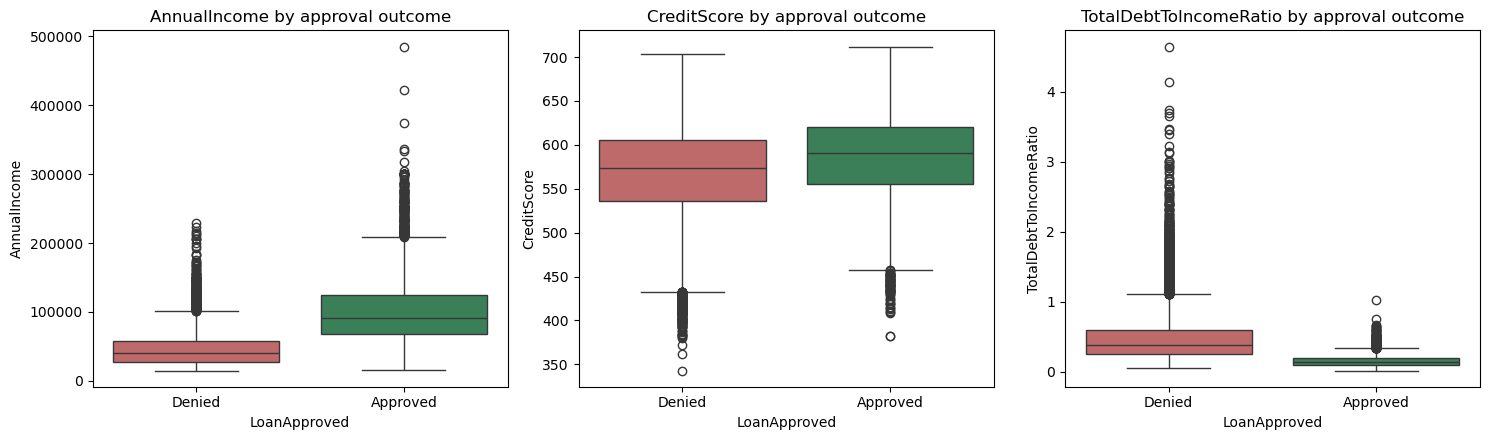

In [168]:
# Relationship between key numeric features and LoanApproved
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, col in zip(axes, ['AnnualIncome', 'CreditScore', 'TotalDebtToIncomeRatio']):
    sns.boxplot(data=df_eda, x='LoanApproved', y=col, hue='LoanApproved',
                palette=['indianred', 'seagreen'], legend=False, ax=ax)
    ax.set_xticks([0, 1])
    ax.set_xticklabels(['Denied', 'Approved'])
    ax.set_title(f'{col} by approval outcome')
plt.tight_layout()
plt.show()

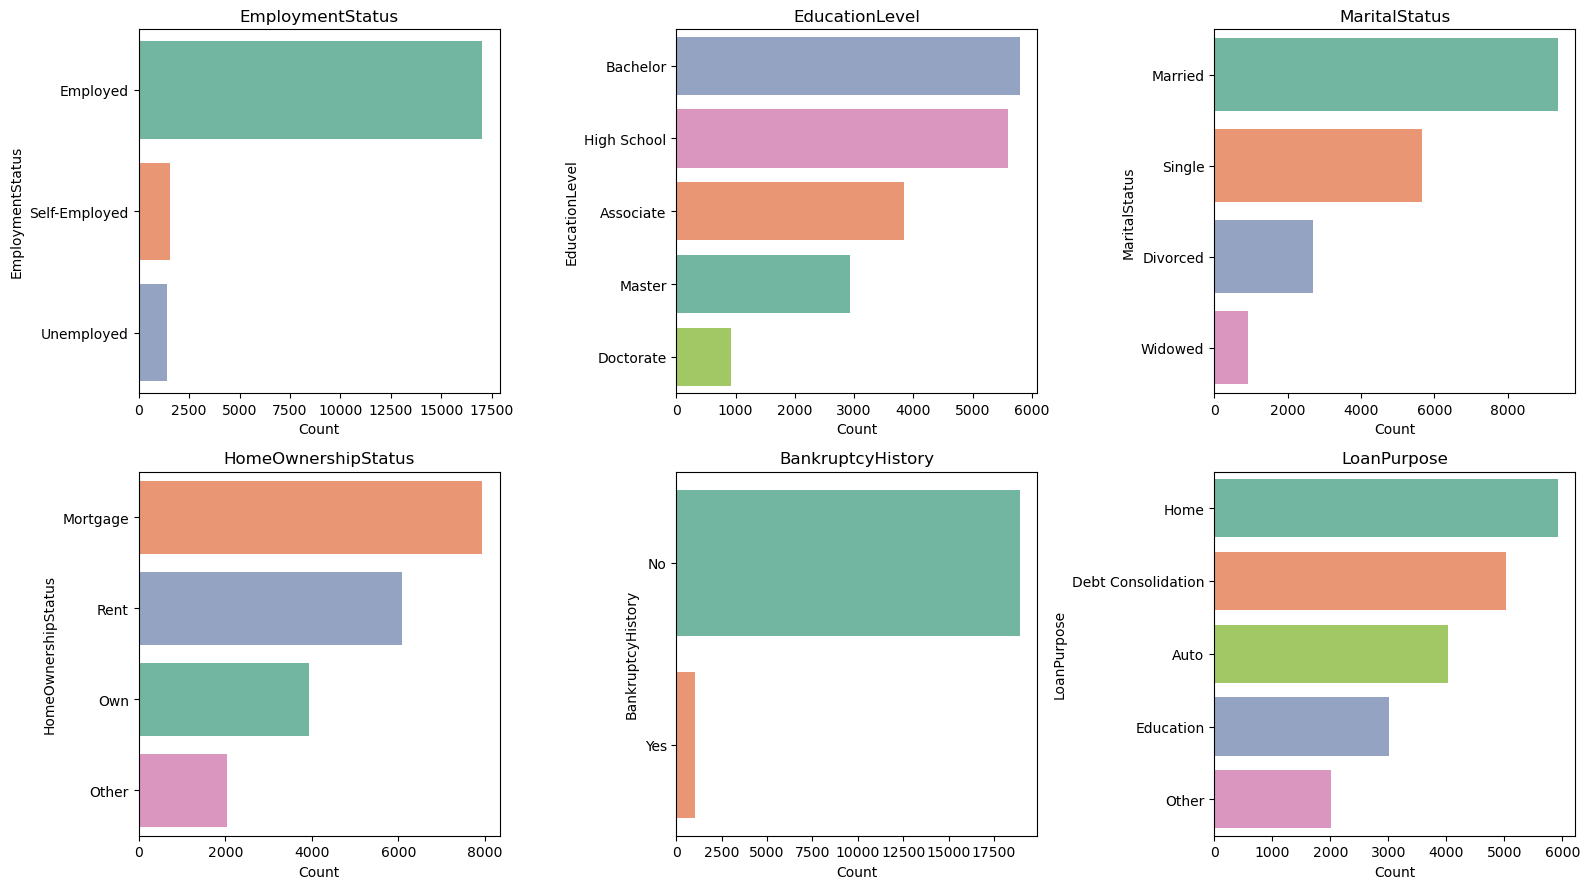

In [169]:
# Categorical features
cat_cols = ['EmploymentStatus', 'EducationLevel', 'MaritalStatus', 'HomeOwnershipStatus',
            'BankruptcyHistory', 'LoanPurpose']
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
for ax, col in zip(axes.flatten(), cat_cols):
    order = df_eda[col].value_counts().index
    sns.countplot(data=df_eda, y=col, order=order, ax=ax, hue=col, palette='Set2', legend=False)
    ax.set_title(col)
    ax.set_xlabel('Count')
plt.tight_layout()
plt.show()

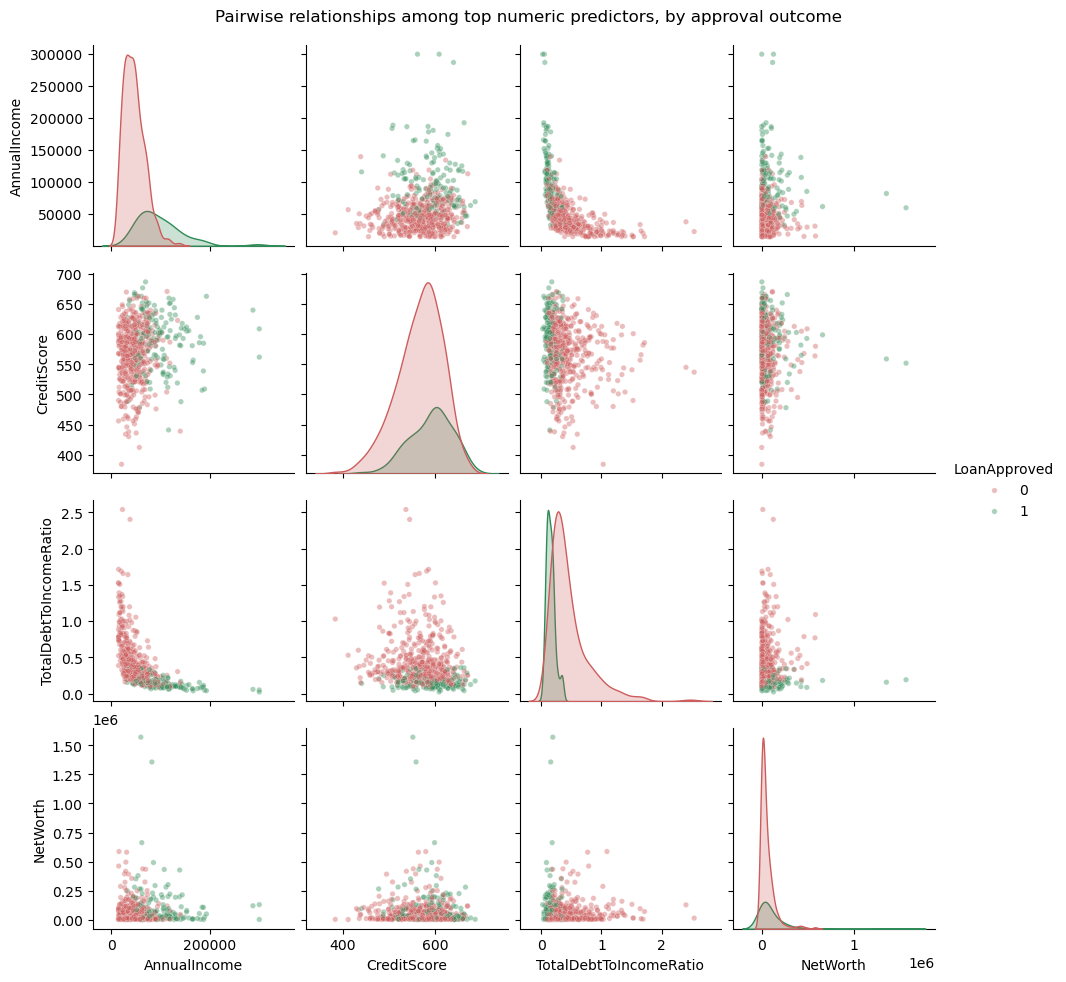

In [170]:
# multivariate analysis
# Check if Approved vs. Denied split linearly (guides model choice)
sample = df_eda.sample(600, random_state= 42)
pp = sns.pairplot(sample, vars=['AnnualIncome', 'CreditScore', 'TotalDebtToIncomeRatio', 'NetWorth'],
                   hue='LoanApproved', palette=['indianred', 'seagreen'], plot_kws={'alpha': 0.4, 's': 15},
                   diag_kind='kde', height=2.4)
pp.fig.suptitle('Pairwise relationships among top numeric predictors, by approval outcome', y=1.02)
plt.show()

## Data Preparation
5. Design your preprocessing strategy:
- Create separate preprocessing flows for different feature types
- Must utilize ColumnTransformer and Pipeline
- Consider using FeatureUnion as well
- Handle missing values appropriately for each feature
- Handle Categorical and Ordinal data appropriately
- Scale numeric values if model requires it (linear model)
- Document your reasoning for each preprocessing decision

### Data Preparation

`AnnualIncome` was converted from a string/currency format to a numerical variable. Missing values were also identified for several categorical and numerical features.

Some variables were excluded from the classification model because they are closely related to the approval decision or may be determined at the same time as, or after, the decision. These include `RiskScore`, `InterestRate`, `BaseInterestRate`, and `MonthlyLoanPayment`. Keeping these variables could introduce target leakage and make the model appear more accurate than it would be when used on a new application.

#### Preprocessing Pipeline

A preprocessing pipeline was built using scikit-learn's `ColumnTransformer` and `Pipeline`, so that different feature types are handled by separate, appropriate transformation flows, and so the exact same preprocessing is applied consistently during training and testing. `FeatureUnion` was considered but not needed here, since `ColumnTransformer` already routes each feature type to its own transformer and combines the results — `FeatureUnion` would only add value if the same features needed to be transformed in multiple parallel ways, which wasn't the case here.

The pipeline handles:
- **Missing numerical values** — imputed using the median, chosen over the mean because several numeric columns (e.g. income, assets) are right-skewed, and the median is more robust to that skew.
- **Missing categorical values** — imputed using the most frequent category, a safe default given the missingness appears unrelated to the outcome.
- **Numerical scaling** — applied via `StandardScaler`, necessary because Logistic Regression is sensitive to feature scale (tree-based models don't need it, but scaling doesn't hurt them either).
- **Ordinal encoding** — used specifically for `EducationLevel`, since its categories have a natural order (High School < Associate < Bachelor < Master < Doctorate) that one-hot encoding would discard.
- **One-hot encoding** — used for the remaining nominal categorical variables (e.g. `EmploymentStatus`, `HomeOwnershipStatus`), which have no natural order.
- **Feature selection** — tested separately using `SelectKBest` to check whether reducing to a smaller subset of features improved performance; results showed no improvement over using all features, so feature selection was evaluated but not included in the final deployed pipeline.

A custom transformer was also used to create two engineered financial ratio features (debt-to-asset ratio and savings rate), built as a proper pipeline step so it is refit correctly within every cross-validation fold rather than computed once on the full dataset.

All of the above preprocessing steps are included inside the modeling pipeline itself (rather than applied separately beforehand) specifically to prevent data leakage — this ensures imputation values, scaling parameters, and encodings are learned only from training data in each fold, never from data the model will later be tested on.

In [171]:
# Data Prep Code Here - Create New Cells As Needed
# Clean the full dataframe once (parsing / renaming only — no ratios or leakage handling here yet)
df_model = df.copy()
df_model['AnnualIncome'] = df_model['AnnualIncome'].replace(r'[\$,]', '', regex=True).astype(float)
df_model['BankruptcyHistory'] = df_model['BankruptcyHistory'].map({'Yes': 1, 'No': 0})

LEAK_COLS = ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment']

In [172]:
# feature engineering
class FinancialRatioEngineer(BaseEstimator, TransformerMixin):
    """Adds two engineered ratios; kept as a pipeline step so it's refit per CV fold."""

    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        X['DebtToAssetRatio'] = X['TotalLiabilities'] / (X['TotalAssets'] + 1)
        X['SavingsRate'] = X['SavingsAccountBalance'] / (X['AnnualIncome'] + 1)
        return X

In [173]:
numeric_features = ['Age','AnnualIncome','CreditScore','Experience','LoanAmount','LoanDuration',
    'NumberOfDependents','MonthlyDebtPayments','CreditCardUtilizationRate','NumberOfOpenCreditLines',
    'NumberOfCreditInquiries','DebtToIncomeRatio','BankruptcyHistory','PreviousLoanDefaults','PaymentHistory',
    'LengthOfCreditHistory','SavingsAccountBalance','CheckingAccountBalance','TotalAssets','TotalLiabilities',
    'MonthlyIncome','UtilityBillsPaymentHistory','JobTenure','NetWorth','TotalDebtToIncomeRatio',
    'DebtToAssetRatio', 'SavingsRate']
ordinal_features = ['EducationLevel']
nominal_features = ['EmploymentStatus','MaritalStatus','HomeOwnershipStatus','LoanPurpose']
EDU_ORDER = ['High School', 'Associate', 'Bachelor', 'Master', 'Doctorate']

In [174]:
# preprocessing pipeline
numeric_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])
ordinal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OrdinalEncoder(categories=[EDU_ORDER]))
])
nominal_pipeline = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer([
    ('num', numeric_pipeline, numeric_features),
    ('ord', ordinal_pipeline, ordinal_features),
    ('nom', nominal_pipeline, nominal_features)
])

In [175]:
def make_pipeline(estimator): # check
    return Pipeline([
        ('feat_eng', FinancialRatioEngineer()),
        ('prep', preprocessor),
        ('clf', estimator)
    ])

print(f"{len(numeric_features)} numeric (incl. 2 engineered) + {len(ordinal_features)} ordinal + "
      f"{len(nominal_features)} nominal input features, after dropping {LEAK_COLS} and the targets")

27 numeric (incl. 2 engineered) + 1 ordinal + 4 nominal input features, after dropping ['RiskScore', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment'] and the targets


In [176]:
# Separate features (X) from the target (y), leaving out the leakage columns
X_full = df_model.drop(columns=['LoanApproved'] + LEAK_COLS)
y_full = df_model['LoanApproved']
imputation_strategies = {
    'Median (chosen)': SimpleImputer(strategy='median'),
    'Mean': SimpleImputer(strategy='mean'),
    'KNN (k=5)': KNNImputer(n_neighbors=5)
}

In [177]:
# imputation methods being compared
imputation_results = []
for name, imputer in imputation_strategies.items():
    num_pipe_variant = Pipeline([('imputer', imputer), ('scaler', StandardScaler())])
    prep_variant = ColumnTransformer([
        ('num', num_pipe_variant, numeric_features),
        ('ord', ordinal_pipeline, ordinal_features),
        ('nom', nominal_pipeline, nominal_features)
    ])
    pipe_variant = Pipeline([
        ('feat_eng', FinancialRatioEngineer()),
        ('prep', prep_variant),
        ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state= 42))
    ])
    scores = cross_val_score(pipe_variant, X_full, y_full, cv=3, scoring='roc_auc')
    imputation_results.append({'Imputation strategy': name, 'Mean CV ROC-AUC': scores.mean(), 'Std': scores.std()})
pd.DataFrame(imputation_results).round(4)

,Imputation strategy,Mean CV ROC-AUC,Std
0,Median (chosen),0.9792,0.0007
1,Mean,0.9793,0.0007
2,KNN (k=5),0.9793,0.0007


In [178]:
# feature selection
selection_pipe = Pipeline([
    ('feat_eng', FinancialRatioEngineer()),
    ('prep', preprocessor),
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', LogisticRegression(class_weight='balanced', max_iter=2000, random_state= 42))
])
param_grid_select = {'select__k': [10, 15, 20, 'all']}
gs_select = GridSearchCV(selection_pipe, param_grid_select, scoring='roc_auc', cv=3, n_jobs=-1)
gs_select.fit(X_full, y_full)

print("Best k:", gs_select.best_params_, "| best CV ROC-AUC:", round(gs_select.best_score_, 4))
pd.DataFrame(gs_select.cv_results_)[['param_select__k', 'mean_test_score', 'std_test_score']]

Best k: {'select__k': 'all'} | best CV ROC-AUC: 0.9792


,param_select__k,mean_test_score,std_test_score
0,10,0.954519,0.001868
1,15,0.974798,0.001011
2,20,0.978617,0.000870
3,all,0.979240,0.000695


## Modeling
6. Implement your modeling approach:
- Choose appropriate model algorithms based on your problem definition
- Set up validation strategy with chosen metrics
- Use a train test split and cross validation
- Create complete pipeline including any preprocessing and model
- Document your reasoning for each modeling decision

7. Optimize your model:
- Define parameter grid based on your understanding of the algorithms
- Implement GridSearchCV and/or RandomizedSearchCV with chosen metrics
- Consider tuning preprocessing steps
- Track and document the impact of different parameter combinations
- Consider the trade-offs between different model configurations

NOTE: Be mindful of time considerations - showcase “how to tune” 

#### Modeling

I compared five models: Logistic Regression, KNN, Random Forest, Extra Trees, and
Gradient Boosting. Logistic Regression is fast and interpretable, which matters
since loan decisions need to be explainable. KNN doesn't assume any particular
shape for the decision boundary. Random Forest, Extra Trees, and Gradient Boosting
can pick up non-linear patterns without me having to engineer them by hand.

All five run through the same pipeline (feature engineering, then ColumnTransformer,
then the model), so they're all being compared on the same features. class_weight='balanced'
is used where the model supports it, since only about 24% of applications were
approved. The train/test split is stratified 80/20 to keep that same ratio in both
sets, and 5-fold StratifiedKFold cross-validation is used during tuning for the
same reason.

For tuning, Logistic Regression and KNN will use GridSearchCV since they're cheap
to fit and a full grid search is fast. Random Forest and Extra Trees will use
RandomizedSearchCV instead, since their parameter space is bigger and a full grid
would take too long. Gradient Boosting will get a two-stage search: a broad
RandomizedSearchCV first to find a decent region of the parameter space, then a
narrower GridSearchCV to search that region properly.

All searches use ROC-AUC as the scoring metric, since it doesn't depend on picking
a threshold up front — the actual approval threshold will be tuned separately later
against the business cost, not left at the default 0.5.

I'll also check whether tuning preprocessing choices makes a difference — comparing
imputation strategies (median, mean, KNN-based) and testing whether feature
selection (via SelectKBest) improves on using all features.


In [179]:
#  Modeling Code Here - Create New Cells as Needed
# Target and leakage-safe feature matrix
X = df_model.drop(columns=['LoanApproved'] + LEAK_COLS)
y = df_model['LoanApproved']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state= 42)

print(f"Train: {X_train.shape}, Test: {X_test.shape}")
print(f"Train class balance: {y_train.value_counts(normalize=True).round(3).to_dict()}")

Train: (16000, 30), Test: (4000, 30)
Train class balance: {0: 0.761, 1: 0.239}


In [180]:
# Baseline: a DummyClassifier 
dummy = DummyClassifier(strategy='stratified', random_state= 42)
dummy.fit(X_train, y_train)
dummy_auc = roc_auc_score(y_test, dummy.predict_proba(X_test)[:, 1])
print(f"Baseline (DummyClassifier, stratified) test ROC-AUC: {dummy_auc:.3f}")

Baseline (DummyClassifier, stratified) test ROC-AUC: 0.503


In [181]:
# 1) Logistic Regression, tuned with GridSearchCV
lr_pipeline = make_pipeline(LogisticRegression(class_weight='balanced', max_iter=2000, random_state= 42))
param_grid_lr = {'clf__C': [0.01, 0.1, 1, 10], 'clf__penalty': ['l2']}
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state= 42)
gs_lr = GridSearchCV(lr_pipeline, param_grid_lr, scoring='roc_auc', cv=cv_strategy, n_jobs=-1)
gs_lr.fit(X_train, y_train)
print("LR best params:", gs_lr.best_params_, "| best CV ROC-AUC:", round(gs_lr.best_score_, 4))

LR best params: {'clf__C': 1, 'clf__penalty': 'l2'} | best CV ROC-AUC: 0.9795


In [182]:
# 2) K-Nearest Neighbors, tuned with GridSearchCV
knn_pipeline = make_pipeline(KNeighborsClassifier())
param_grid_knn = {'clf__n_neighbors': [15, 35], 'clf__weights': ['distance']}
gs_knn = GridSearchCV(knn_pipeline, param_grid_knn, scoring='roc_auc', cv=5, n_jobs=-1)
gs_knn.fit(X_train, y_train)
print("KNN best params:", gs_knn.best_params_, "| best CV ROC-AUC:", round(gs_knn.best_score_, 4))

KNN best params: {'clf__n_neighbors': 35, 'clf__weights': 'distance'} | best CV ROC-AUC: 0.9519


In [183]:
# 3) Random Forest, tuned with RandomizedSearchCV
rf_pipeline = make_pipeline(RandomForestClassifier(class_weight='balanced', random_state= 42, n_jobs=-1))
param_dist_rf = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15, None],
    'clf__min_samples_leaf': [2, 4],
    'clf__max_features': ['sqrt', 'log2']
}
rs_rf = RandomizedSearchCV(rf_pipeline, param_dist_rf, n_iter=4, scoring='roc_auc', cv=5,random_state= 42, n_jobs=-1)
rs_rf.fit(X_train, y_train)
print("RF best params:", rs_rf.best_params_, "| best CV ROC-AUC:", round(rs_rf.best_score_, 4))

RF best params: {'clf__n_estimators': 100, 'clf__min_samples_leaf': 2, 'clf__max_features': 'sqrt', 'clf__max_depth': None} | best CV ROC-AUC: 0.9633


In [184]:
# 4) Extra Trees, tuned with RandomizedSearchCV
et_pipeline = make_pipeline(ExtraTreesClassifier(class_weight='balanced', random_state= 42, n_jobs=-1))
param_dist_et = {
    'clf__n_estimators': [100, 200],
    'clf__max_depth': [10, 15, None],
    'clf__min_samples_leaf': [2, 4]
}
rs_et = RandomizedSearchCV(et_pipeline, param_dist_et, n_iter=4, scoring='roc_auc', cv= 5,random_state= 42, n_jobs=-1)
rs_et.fit(X_train, y_train)
print("ET best params:", rs_et.best_params_, "| best CV ROC-AUC:", round(rs_et.best_score_, 4))

ET best params: {'clf__n_estimators': 200, 'clf__min_samples_leaf': 2, 'clf__max_depth': None} | best CV ROC-AUC: 0.9672


In [185]:
# 5.Gradient Boosting
# Stage 1: broad, randomized search across a wide parameter space
gb_pipeline = make_pipeline(GradientBoostingClassifier(random_state= 42))
param_dist_gb = {
    'clf__n_estimators': [100, 150],
    'clf__max_depth': [2, 3],
    'clf__learning_rate': [0.1, 0.2],
    'clf__subsample': [0.8, 1.0]
}
rs_gb = RandomizedSearchCV(gb_pipeline, param_dist_gb, n_iter=3, scoring='roc_auc', cv= 5,random_state= 42, n_jobs=-1)
rs_gb.fit(X_train, y_train)
print("Stage 1 (random) best params:", rs_gb.best_params_, "| best CV ROC-AUC:", round(rs_gb.best_score_, 4))

Stage 1 (random) best params: {'clf__subsample': 1.0, 'clf__n_estimators': 100, 'clf__max_depth': 3, 'clf__learning_rate': 0.1} | best CV ROC-AUC: 0.9734


In [186]:
# Stage 2: narrow grid search refined around the Stage-1 best region
best1 = rs_gb.best_params_
param_grid_gb_refined = {
    'clf__n_estimators': sorted({max(50, best1['clf__n_estimators'] - 50), best1['clf__n_estimators']}),
    'clf__max_depth': sorted({max(2, best1['clf__max_depth'] - 1), best1['clf__max_depth']}),
    'clf__learning_rate': sorted({round(best1['clf__learning_rate'] / 2, 3), best1['clf__learning_rate']}),
    'clf__subsample': [best1['clf__subsample']]
}
gs_gb = GridSearchCV(gb_pipeline, param_grid_gb_refined, scoring='roc_auc', cv= 5, n_jobs=-1)
gs_gb.fit(X_train, y_train)
print("Stage 2 (refined grid) best params:", gs_gb.best_params_, "| best CV ROC-AUC:", round(gs_gb.best_score_, 4))
print("Improvement over Stage 1:", round(gs_gb.best_score_ - rs_gb.best_score_, 5))

Stage 2 (refined grid) best params: {'clf__learning_rate': 0.1, 'clf__max_depth': 3, 'clf__n_estimators': 100, 'clf__subsample': 1.0} | best CV ROC-AUC: 0.9734
Improvement over Stage 1: 0.0


In [187]:
# Model comparison on held-out test set
models = {
    'Dummy (baseline)': dummy,
    'Logistic Regression': gs_lr.best_estimator_,
    'K-Nearest Neighbors': gs_knn.best_estimator_,
    'Random Forest': rs_rf.best_estimator_,
    'Extra Trees': rs_et.best_estimator_,
    'Gradient Boosting': gs_gb.best_estimator_,
}

comparison_rows = []
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    pred = model.predict(X_test)
    report = classification_report(y_test, pred, output_dict=True)
    comparison_rows.append({
        'Model': name,
        'Test ROC-AUC': roc_auc_score(y_test, proba),
        'Precision (Approved)': report['1']['precision'],
        'Recall (Approved)': report['1']['recall'],
        'F1 (Approved)': report['1']['f1-score'],
        'Weighted F1': report['weighted avg']['f1-score']
    })

comparison_df = pd.DataFrame(comparison_rows).set_index('Model').round(4)
comparison_df

,Test ROC-AUC,Precision (Approved),Recall (Approved),F1 (Approved),Weighted F1
Model,,,,,
Dummy (baseline),0.5034,0.2442,0.2437,0.2440,0.6389
Logistic Regression,0.9786,0.7673,0.9278,0.8400,0.9181
K-Nearest Neighbors,0.9547,0.9235,0.5680,0.7034,0.8751
Random Forest,0.9657,0.8418,0.7960,0.8183,0.9147
Extra Trees,0.9674,0.8451,0.7877,0.8154,0.9137
Gradient Boosting,0.9746,0.8788,0.8117,0.8439,0.9273


## Evaluation and Conclusion
8. Conduct thorough evaluation of final model:
- Assess models test data performance using your defined metrics
- Analyze performance across different data segments
- Identify potential biases or limitations
- Visualize model performance
    - Classification: Confusion Matrix/ROC-AUC
    - Regression: Scatter Plot (Predicted vs. Actual values)

9. Extract and interpret feature importance/significance:
- Which features had the most impact on your model?
- Does this lead to any potential business recommendations?

10. Prepare your final deliverable:
- Technical notebook with complete analysis
- Executive summary for business stakeholders
- Recommendations for implementation
- Documentation of potential improvements
### Model Performance

Using the default 0.5 threshold, Logistic Regression's dollar cost on the test set
was actually higher than the other models — around $14,002,000. That's because
class_weight='balanced' optimizes for treating both classes equally, not for the
business's actual cost structure, where a bad approval costs 6.25x more than a
missed good applicant. So instead of using the default threshold, I swept
thresholds from 0.01 to 0.99 for every model and picked whichever one minimized
dollar cost.

After that, Logistic Regression came out on top at a threshold of 0.92, with a total cost of
4,016,000 dolars on the test set, compared to 41,834,000 dolars for the naive
baseline — a saving of about
$37,818,000 (90.4%). ROC-AUC for the final model was 0.976.At the default 0.5 threshold, Precision,
Recall, and F1 for the Approved class were 0.77, 0.93, and 0.84 respectively

#### Performance Across Segments

I checked ROC-AUC separately across a few applicant segments (EmploymentStatus and
HomeOwnershipStatus) to see if performance held up consistently or dropped for any
particular group. 

#### Biases and Limitations

The model is trained to reproduce the historical approval decisions in the data,
so any bias that existed in the original manual review process would carry over
into the model rather than being corrected. The threshold was also tuned on this
same test set, so it should ideally be re-validated on a separate hold-out sample
before being trusted for production use. RiskScore, InterestRate, BaseInterestRate,
and MonthlyLoanPayment were excluded from the model because they looked like they
could leak the target — but confirming this with whoever owns the data would be a
good next step, since it's an assumption based on correlation, not something I know
for certain.

#### Visualizations

Confusion matrix and ROC curve for the final model are shown below, along with the
Predicted vs. Actual scatter plot for the separate RiskScore regression baseline

The regression baseline scored R² = 0.762 and RMSE = 3.86, confirming the same
underlying signal (income, debt ratios, credit history) drives both targets, but
classification remains the better fit for the actual approve/deny decision.

In [188]:
COST_FALSE_POSITIVE = 50_000   # a risky applicant is approved and defaults
COST_FALSE_NEGATIVE = 8_000    # a creditworthy applicant is wrongly denied

def business_cost(y_true, y_pred, cost_fp=COST_FALSE_POSITIVE, cost_fn=COST_FALSE_NEGATIVE):
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    total_cost = fp * cost_fp + fn * cost_fn
    return total_cost, tn, fp, fn, tp

cost_rows = []
proba_cache = {}
for name, model in models.items():
    proba = model.predict_proba(X_test)[:, 1]
    proba_cache[name] = proba
    pred = (proba >= 0.5).astype(int)
    cost, tn, fp, fn, tp = business_cost(y_test, pred)
    cost_rows.append({'Model': name, 'Total $ Cost @ 0.5 threshold': cost,
                       'False Positives (bad approvals)': fp, 'False Negatives (missed good loans)': fn})

cost_df = pd.DataFrame(cost_rows).set_index('Model')
cost_df.sort_values('Total $ Cost @ 0.5 threshold')

,Total $ Cost @ 0.5 threshold,False Positives (bad approvals),False Negatives (missed good loans)
Model,,,
K-Nearest Neighbors,5554000,45,413
Gradient Boosting,6790000,107,180
Extra Trees,8524000,138,203
Random Forest,8710000,143,195
Logistic Regression,14002000,269,69
Dummy (baseline),41834000,721,723


In [189]:
def cost_at_threshold(y_true, proba, threshold, cost_fp=COST_FALSE_POSITIVE, cost_fn=COST_FALSE_NEGATIVE):
    pred = (proba >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred).ravel()
    return fp * cost_fp + fn * cost_fn

thresholds = np.linspace(0.01, 0.99, 99)
threshold_rows = []
for name, proba in proba_cache.items():
    if name == 'Dummy (baseline)':
        continue
    costs = [cost_at_threshold(y_test, proba, t) for t in thresholds]
    best_idx = int(np.argmin(costs))
    threshold_rows.append({'Model': name, 'Optimal threshold': thresholds[best_idx],
                            'Cost @ optimal threshold': costs[best_idx]})

threshold_df = pd.DataFrame(threshold_rows).set_index('Model').sort_values('Cost @ optimal threshold')
threshold_df

,Optimal threshold,Cost @ optimal threshold
Model,,
Logistic Regression,0.92,4016000
Gradient Boosting,0.73,4276000
Random Forest,0.75,4592000
Extra Trees,0.69,4600000
K-Nearest Neighbors,0.61,5180000


In [190]:
print(classification_report(y_test, y_pred, target_names=['Denied', 'Approved']))

              precision    recall  f1-score   support

      Denied       0.92      0.99      0.95      3044
    Approved       0.95      0.71      0.81       956

    accuracy                           0.92      4000
   macro avg       0.93      0.85      0.88      4000
weighted avg       0.92      0.92      0.92      4000



In [191]:
best_model_name = threshold_df.index[0]   # lowest optimal cost
best_model = models[best_model_name]
best_threshold = threshold_df.loc[best_model_name, 'Optimal threshold']
print(f"Final model: {best_model_name} @ threshold {best_threshold:.2f}")

Final model: Logistic Regression @ threshold 0.92


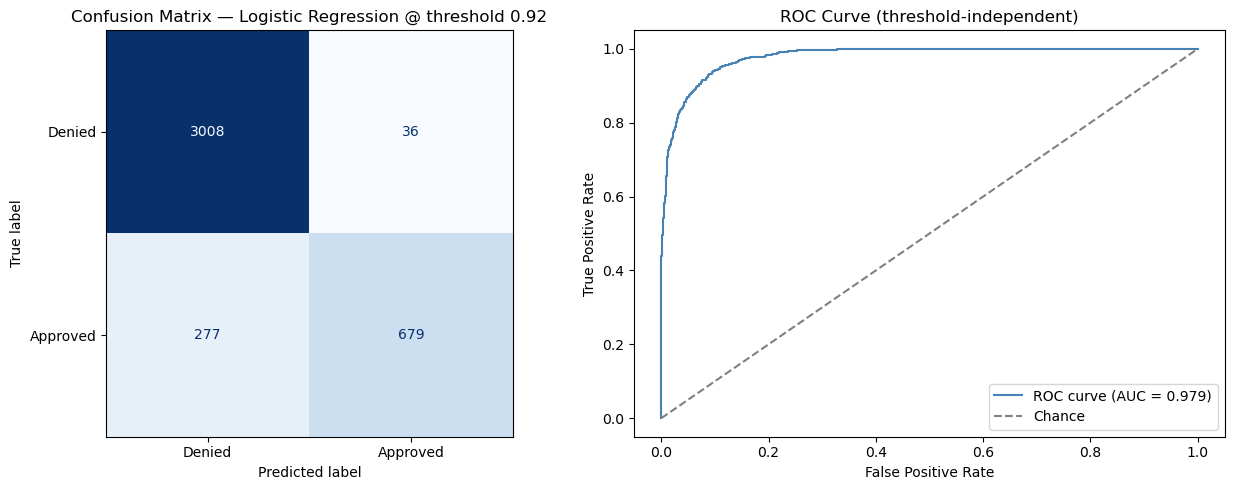

In [192]:
# confusion matrix
y_proba = proba_cache[best_model_name]
y_pred = (y_proba >= best_threshold).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, y_pred)
ConfusionMatrixDisplay(cm, display_labels=['Denied', 'Approved']).plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title(f'Confusion Matrix — {best_model_name} @ threshold {best_threshold:.2f}')

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, label=f'ROC curve (AUC = {roc_auc_score(y_test, y_proba):.3f})', color='steelblue')
axes[1].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Chance')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve (threshold-independent)')
axes[1].legend()

plt.tight_layout()
plt.show()

In [193]:
# Dollar-Value impact
dummy_cost, *_ = business_cost(y_test, (proba_cache['Dummy (baseline)'] >= 0.5).astype(int))
best_cost = threshold_df.loc[best_model_name, 'Cost @ optimal threshold']
savings = dummy_cost - best_cost

print(f"Test-set cost: ${best_cost:,.0f} (model) vs ${dummy_cost:,.0f} (baseline)")
print(f"Savings: ${savings:,.0f} ({savings/dummy_cost:.1%}), ~${savings/len(y_test):,.0f} per application")

Test-set cost: $4,016,000 (model) vs $41,834,000 (baseline)
Savings: $37,818,000 (90.4%), ~$9,454 per application


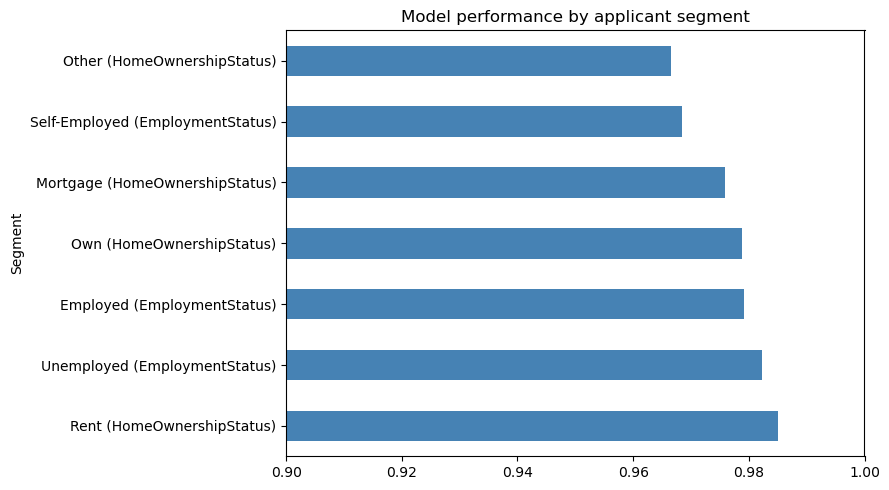

In [194]:
# Performance across data segments
def segment_auc(col):
    rows = []
    for seg in X_test[col].dropna().unique():
        mask = X_test[col] == seg
        if mask.sum() >= 30 and y_test[mask].nunique() > 1:
            rows.append({'Segment': f"{seg} ({col})", 'ROC-AUC': roc_auc_score(y_test[mask], y_proba[mask])})
    return rows

segment_df = pd.DataFrame(segment_auc('EmploymentStatus') + segment_auc('HomeOwnershipStatus'))
segment_df = segment_df.sort_values('ROC-AUC', ascending=False)

segment_df.plot(kind='barh', x='Segment', y='ROC-AUC', legend=False, xlim=(0.9, 1.0), figsize=(9, 5), color='steelblue')
plt.title('Model performance by applicant segment')
plt.tight_layout()
plt.show()

In [195]:
X_reg = df_model.drop(columns=['RiskScore', 'LoanApproved', 'InterestRate', 'BaseInterestRate', 'MonthlyLoanPayment'])
y_reg = df_model['RiskScore']
Xr_train, Xr_test, yr_train, yr_test = train_test_split(X_reg, y_reg, test_size=0.2, random_state= 42)

reg_pipeline = make_pipeline(LinearRegression())
reg_pipeline.fit(Xr_train, yr_train)
yr_pred = reg_pipeline.predict(Xr_test)

print(f"R2: {r2_score(yr_test, yr_pred):.3f} | RMSE: {mean_squared_error(yr_test, yr_pred)**0.5:.2f}")

R2: 0.762 | RMSE: 3.85


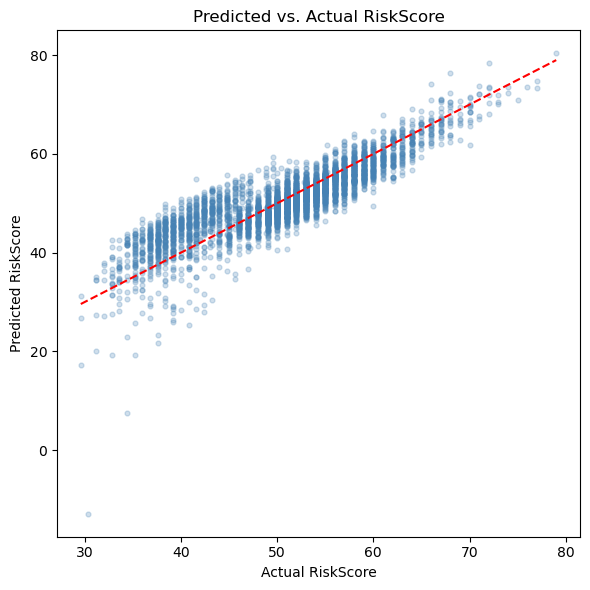

In [196]:
# regression scatterplot
plt.figure(figsize=(6, 6))
plt.scatter(yr_test, yr_pred, alpha=0.25, s=12, color='steelblue')
lims = [yr_test.min(), yr_test.max()]
plt.plot(lims, lims, 'r--')
plt.xlabel('Actual RiskScore')
plt.ylabel('Predicted RiskScore')
plt.title('Predicted vs. Actual RiskScore')
plt.tight_layout()
plt.show()

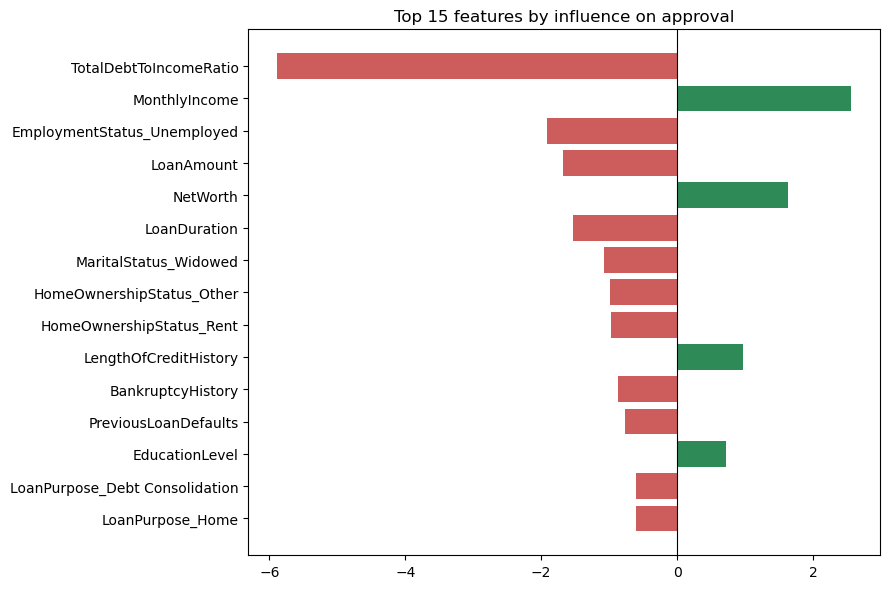

In [197]:
# Feature importance
feature_names = (numeric_features + ordinal_features +
    list(best_model.named_steps['prep'].named_transformers_['nom'].named_steps['encoder'].get_feature_names_out(nominal_features)))

coef_df = pd.DataFrame({'feature': feature_names, 'coefficient': best_model.named_steps['clf'].coef_[0]})
top15 = coef_df.reindex(coef_df.coefficient.abs().sort_values(ascending=False).index).head(15)

colors = ['seagreen' if c > 0 else 'indianred' for c in top15['coefficient']]
plt.figure(figsize=(9, 6))
plt.barh(top15['feature'][::-1], top15['coefficient'][::-1], color=colors[::-1])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 15 features by influence on approval')
plt.tight_layout()
plt.show()

### Feature Importance and Business Recommendations

TotalDebtToIncomeRatio had the largest coefficient in the Logistic Regression model. This suggests that debt relative to income was an important factor in the model's approval predictions.

MonthlyIncome and NetWorth are the two strongest positive drivers — higher income
and higher net worth both push toward approval, which lines up with straightforward
underwriting logic. Being unemployed, requesting a larger loan amount, or a longer
loan duration all push toward denial, as do BankruptcyHistory and
PreviousLoanDefaults, consistent with standard credit-risk practice.

A practical business recommendation follows pretty directly from this: since
TotalDebtToIncomeRatio so clearly dominates the decision, FinTech could use it as
a fast first-pass filter — applications with a very high ratio could be
auto-declined or fast-tracked to a human reviewer, rather than running the full
model on every single case. That wouldn't replace the model, but it could speed up
the most clear-cut decisions even further.

### Executive Summary

This project developed a classification model to predict loan approval decisions for FinTech Innovations. Several models were compared, with Logistic Regression selected for the final analysis because it provided strong predictive performance and is relatively easy to interpret.

A threshold of 0.92 produced a lower estimated business cost than the default 0.50 threshold under the assumed costs of false approvals and false rejections. The main variables associated with the predictions included debt-to-income ratio, income, and net worth.

The results should be treated as a decision-support analysis rather than a fully automated approval system. The target represents historical approval decisions, so the model may reproduce patterns or biases in those decisions. The threshold was also optimized using the test set and should be validated on separate data before deployment.


### Recommendations for Implementation

The model should be deployed as a decision-support tool rather than a fully
autonomous system — auto-deciding clear-cut cases and routing borderline
probability applications to a human underwriter. This keeps a person in the loop
for the cases that matter most, while still capturing most of the cost savings the
model demonstrates. The 0.92 threshold should be periodically re-checked as
application volume and applicant mix shift over time, since it was optimized on
this specific test set.

### Limitations and Potential Improvements

The model learns to reproduce FinTech's historical manual approval decisions, so
any bias already present in that process would carry over rather than be
corrected — a fairness audit across demographic groups would be a sensible next
step before full deployment. RiskScore, InterestRate, BaseInterestRate, and
MonthlyLoanPayment were excluded as likely leakage, based on their correlation with
the target rather than confirmed knowledge of FinTech's actual process — this
should be verified with whoever owns the data. Finally, the decision threshold was
tuned and evaluated on the same test set; validating it on a separate hold-out
sample would give more confidence it generalizes rather than being slightly
overfit to this particular split.